# Business Understanding

## Project Domain

Proyek ini bertujuan untuk membangun model machine learning yang dapat memprediksi informasi penting tentang motor bekas, seperti harga, kondisi, dan riwayat servis. Informasi ini dapat membantu pembeli dan penjual dalam proses jual beli motor bekas.

## Problem Statements

Pembeli: Kesulitan dalam menentukan harga yang wajar dan menilai kondisi motor bekas secara akurat.
Penjual: Kesulitan dalam menentukan harga jual yang optimal dan menarik minat pembeli.
Platform Jual Beli: Kebutuhan untuk memberikan informasi yang akurat dan transparan kepada pengguna.

## Goals

Mengembangkan model yang dapat memprediksi harga dan kondisi motor bekas secara akurat.
Meningkatkan transparansi dalam proses jual beli motor bekas.
Membantu pembeli dan penjual dalam membuat keputusan yang lebih tepat.
Memudahkan platform jual beli dalam memvalidasi informasi yang diberikan oleh pengguna.

## Solution Statements

Model machine learning dapat dilatih dengan data historis motor bekas, seperti merek, model, tahun pembuatan, jarak tempuh, riwayat servis, dan harga jual. Model ini kemudian dapat digunakan untuk:

Memprediksi harga jual motor bekas berdasarkan karakteristiknya.
Menilai kondisi motor bekas berdasarkan riwayat servis dan informasi lainnya.
Memberikan rekomendasi kepada pembeli dan penjual tentang harga yang wajar.
Mendeteksi potensi penipuan dengan mengidentifikasi informasi yang tidak konsisten.

# Data Understanding

## Import data dari kaggle

In [ ]:
import numpy as np
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"muhammadmalikibrahim","key":"97aa2b4d45d4c193ee96b6e8f6e7a907"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [ ]:
!kaggle datasets download -d nehalbirla/motorcycle-dataset

Dataset URL: https://www.kaggle.com/datasets/nehalbirla/motorcycle-dataset
License(s): DbCL-1.0


In [ ]:
!kaggle datasets download -d nehalbirla/motorcycle-dataset
!unzip motorcycle-dataset.zip -d motorcycle-dataset
!ls motorcycle-dataset

Dataset URL: https://www.kaggle.com/datasets/nehalbirla/motorcycle-dataset
License(s): DbCL-1.0
motorcycle-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  motorcycle-dataset.zip
  inflating: motorcycle-dataset/BIKE DETAILS.csv  
'BIKE DETAILS.csv'


In [ ]:
!kaggle datasets download -d nehalbirla/motorcycle-dataset

Dataset URL: https://www.kaggle.com/datasets/nehalbirla/motorcycle-dataset
License(s): DbCL-1.0
motorcycle-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


## Import Library yang dibutuhkan

In [ ]:
df = pd.read_csv('motorcycle-dataset/BIKE DETAILS.csv')
df.head()

,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [ ]:
df.shape

(1061, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB


In [ ]:
df.columns

Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')

In [ ]:
df.dtypes

,0
name,object
selling_price,int64
year,int64
seller_type,object
owner,object
km_driven,int64
ex_showroom_price,float64


In [ ]:
df.isnull().sum()

,0
name,0
selling_price,0
year,0
seller_type,0
owner,0
km_driven,0
ex_showroom_price,435


In [ ]:
np.round(df.describe(), 2)

,selling_price,year,km_driven,ex_showroom_price
count,1061.00,1061.00,1061.00,626.00
mean,59638.15,2013.87,34359.83,87958.71
std,56304.29,4.30,51623.15,77496.59
min,5000.00,1988.00,350.00,30490.00
25%,28000.00,2011.00,13500.00,54852.00
50%,45000.00,2015.00,25000.00,72752.50
75%,70000.00,2017.00,43000.00,87031.50
max,760000.00,2020.00,880000.00,1278000.00


## Exploratory Data Analysis

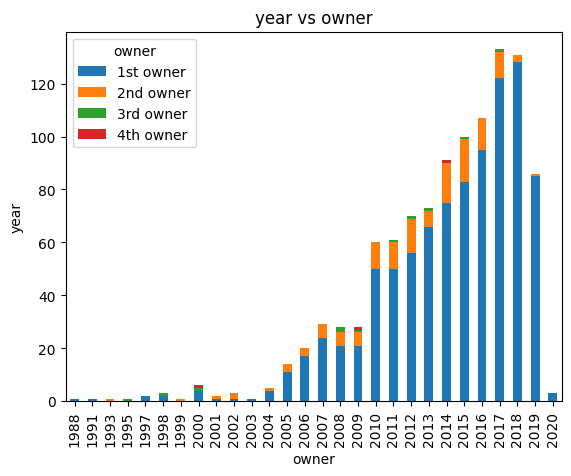

In [ ]:
pd.crosstab(df['year'], df['owner']).plot(kind='bar', stacked=True)
plt.title('year vs owner')
plt.xlabel('owner')
plt.ylabel('year')
plt.show()


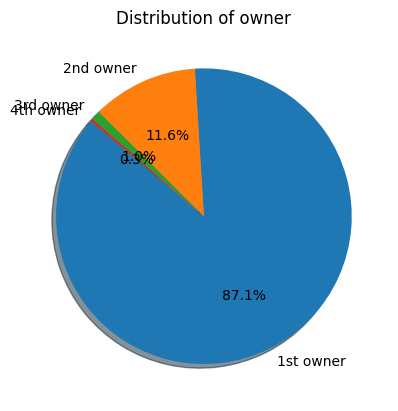

In [ ]:
df['owner'].value_counts().plot(kind='pie', autopct='%1.1f%%',shadow=True,startangle=140)
plt.title('Distribution of owner')
plt.ylabel('')
plt.show()

<Axes: xlabel='selling_price', ylabel='Density'>

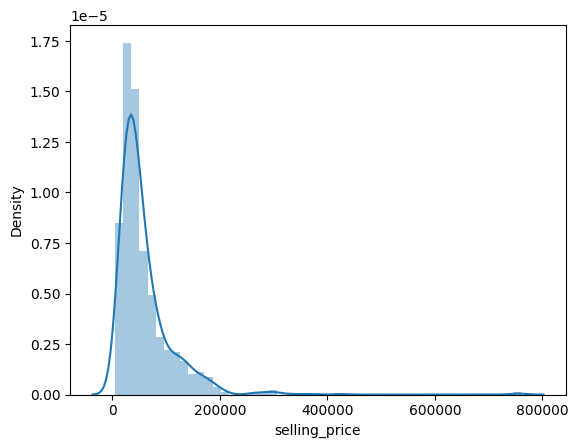

In [ ]:
sns.distplot(df['selling_price'])

<Axes: xlabel='km_driven', ylabel='Density'>

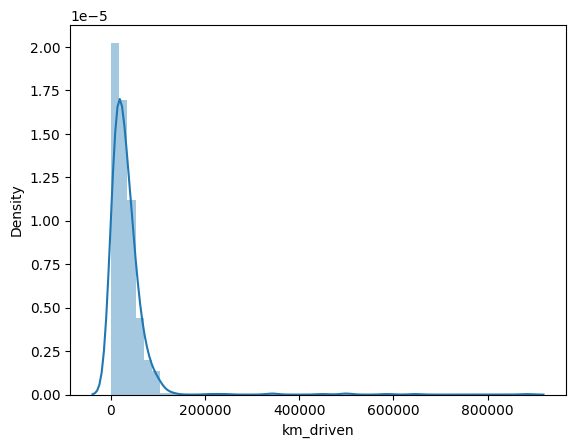

In [ ]:
sns.distplot(df['km_driven'])

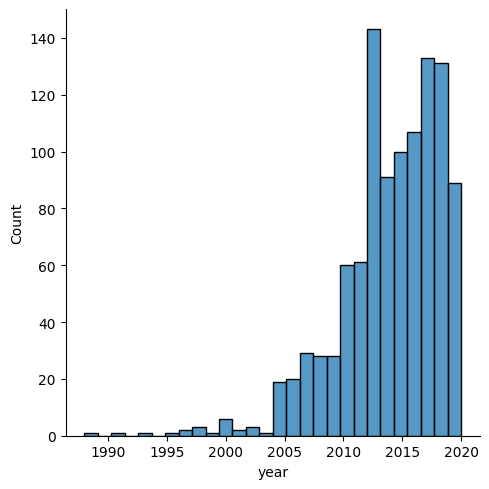

In [ ]:
sns.displot(df['year'])

In [ ]:
highest_bike_purchased_year = df['year'].value_counts().head(10)
highest_bike_purchased_year

,count
year,
2017,133
2018,131
2016,107
2015,100
2014,91
2019,86
2013,73
2012,70
2011,61


<Axes: xlabel='year', ylabel='count'>

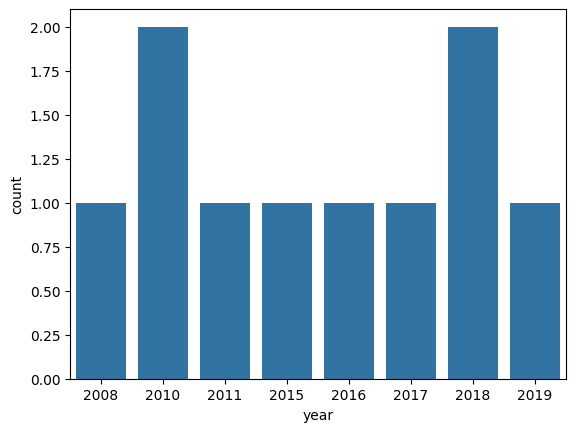

In [ ]:
sns.countplot(x=df['year'].head(10))

In [ ]:
df['ex_showroom_price'].fillna(np.round(df['ex_showroom_price'].mean(), 2), inplace=True)

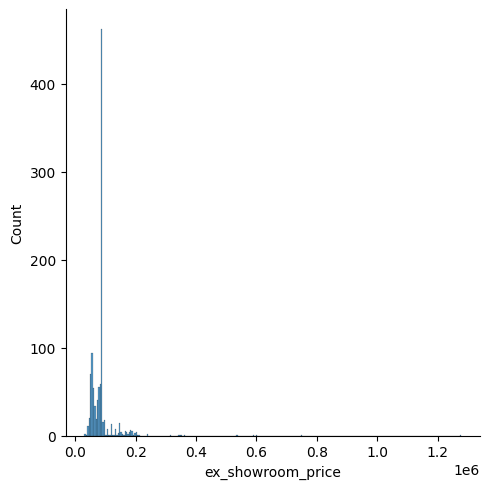

In [ ]:
sns.displot(df['ex_showroom_price'])

In [ ]:
np.round(df['ex_showroom_price'], 2)

,ex_showroom_price
0,87958.71
1,87958.71
2,148114.00
3,89643.00
4,87958.71
...,...
1056,52000.00
1057,51000.00
1058,57000.00
1059,58000.00


# Data Preparation

In [ ]:
df['name'].value_counts().head(15)

,count
name,
Bajaj Pulsar 150,41
Royal Enfield Classic 350,27
Honda Activa [2000-2015],23
Honda CB Hornet 160R,22
Bajaj Pulsar 180,20
Royal Enfield Thunderbird 350,19
Hero Honda Splendor Plus,17
Yamaha FZ S V 2.0,16
Bajaj Discover 125,16


In [ ]:
df['owner'].value_counts()

,count
owner,
1st owner,924
2nd owner,123
3rd owner,11
4th owner,3


In [ ]:
df['seller_type'].value_counts()

,count
seller_type,
Individual,1055
Dealer,6


In [ ]:
df['year'].value_counts().head(10)

,count
year,
2017,133
2018,131
2016,107
2015,100
2014,91
2019,86
2013,73
2012,70
2011,61


# Modeling

In [ ]:
df = pd.get_dummies(df, columns = ['owner', 'seller_type'], drop_first = True)

In [ ]:
df.head(2)

,name,selling_price,year,km_driven,ex_showroom_price,owner_2nd owner,owner_3rd owner,owner_4th owner,seller_type_Individual
0,Royal Enfield Classic 350,175000,2019,350,87958.71,False,False,False,True
1,Honda Dio,45000,2017,5650,87958.71,False,False,False,True


In [ ]:
def bike_model(model_name, excl_honda_hero=False):
    model_list = []
    if excl_honda_hero:
        for i in df['name']:
            if model_name in i and 'Hero' not in i:
                model_list.append(i)
        return model_list
    else:
        for i in df['name']:
            if model_name in i:
                model_list.append(i)
        return model_list

In [ ]:
royal_enfield = bike_model('Royal Enfield')
honda = bike_model('Honda',excl_honda_hero=True)
bajaj = bike_model('Bajaj')
yamaha = bike_model('Yamaha')
suzuki = bike_model('Suzuki')
hero = bike_model('Hero')
tvs = bike_model('TVS')
ktm = bike_model('KTM')

In [ ]:
def brand(i):
    if i in royal_enfield:
        return 'Royal Enfield'
    elif i in honda:
        return 'Honda'
    elif i in bajaj:
        return 'Bajaj'
    elif i in yamaha:
        return 'Yamaha'
    elif i in hero:
        return 'Hero'
    elif i in tvs:
        return 'TVS'
    elif i in suzuki:
        return 'Suzuki'
    elif i in ktm:
        return 'KTM'
    else:
        return 'Other'

In [ ]:
df['brand'] = df['name'].apply(lambda x:brand(x))
df.head()


,name,selling_price,year,km_driven,ex_showroom_price,owner_2nd owner,owner_3rd owner,owner_4th owner,seller_type_Individual,brand
0,Royal Enfield Classic 350,175000,2019,350,87958.71,False,False,False,True,Royal Enfield
1,Honda Dio,45000,2017,5650,87958.71,False,False,False,True,Honda
2,Royal Enfield Classic Gunmetal Grey,150000,2018,12000,148114.00,False,False,False,True,Royal Enfield
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,23000,89643.00,False,False,False,True,Yamaha
4,Yamaha SZ [2013-2014],20000,2011,21000,87958.71,True,False,False,True,Yamaha


In [ ]:
df.drop('name', axis=1, inplace=True)

In [ ]:
df= pd.get_dummies(df, columns=['brand'], drop_first=True)

In [ ]:
df.head(2)

,selling_price,year,km_driven,ex_showroom_price,owner_2nd owner,owner_3rd owner,owner_4th owner,seller_type_Individual,brand_Hero,brand_Honda,brand_KTM,brand_Other,brand_Royal Enfield,brand_Suzuki,brand_TVS,brand_Yamaha
0,175000,2019,350,87958.71,False,False,False,True,False,False,False,False,True,False,False,False
1,45000,2017,5650,87958.71,False,False,False,True,False,True,False,False,False,False,False,False


# Evaluation

In [ ]:
X = df.drop('selling_price', axis=1)
y = df['selling_price']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [ ]:
lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, accuracy_score

In [ ]:
lr.score(X_train, y_train)

0.8041243635476467

# Deployment

## Model Simulation

Hasil Prediksi Harga Motor Bekas: [-7827272.97776716]


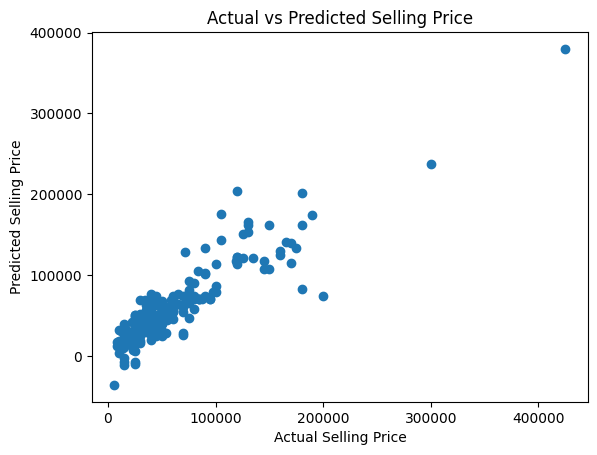

In [ ]:
import numpy as np

# Input data baru (15 fitur) - Sesuaikan dengan fitur yang ada di model Anda
# Pastikan jumlah fitur sesuai dengan yang digunakan saat melatih model
new_data = np.array([[2018, 25000, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]])  # Contoh data baru dengan 15 fitur

# Normalisasi input data baru (asumsikan menggunakan min-max scaling)
# Gantilah dengan metode normalisasi yang sama yang digunakan saat melatih model
# dan pastikan nilai min dan max sesuai dengan fitur yang ada

# Contoh normalisasi (ganti dengan nilai min dan max yang sesuai untuk 15 fitur)
min_values = np.array([2001, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])  # Contoh nilai minimum untuk 15 fitur
max_values = np.array([2021, 100000, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]) # Contoh nilai maksimum untuk 15 fitur

normalized_new_data = (new_data - min_values) / (max_values - min_values)

# Prediksi
prediction = lr.predict(normalized_new_data)

# Hasil prediksi
print("Hasil Prediksi Harga Motor Bekas:", prediction)

plt.scatter(y_test, y_pred)
plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual vs Predicted Selling Price')
plt.show()

     year  km_driven  ex_showroom_price  owner_2nd owner  owner_3rd owner  \
644  2011      35000           75502.00            False            False   
835  2017      35850           87958.71            False            False   
350  2018      37000           87958.71            False            False   
362  2014      33200           67722.00            False            False   
101  2020        500           87958.71            False            False   

     owner_4th owner  seller_type_Individual  brand_Hero  brand_Honda  \
644            False                    True       False        False   
835            False                    True       False         True   
350            False                    True       False        False   
362            False                    True        True        False   
101            False                    True       False        False   

     brand_KTM  brand_Other  brand_Royal Enfield  brand_Suzuki  brand_TVS  \
644      False       

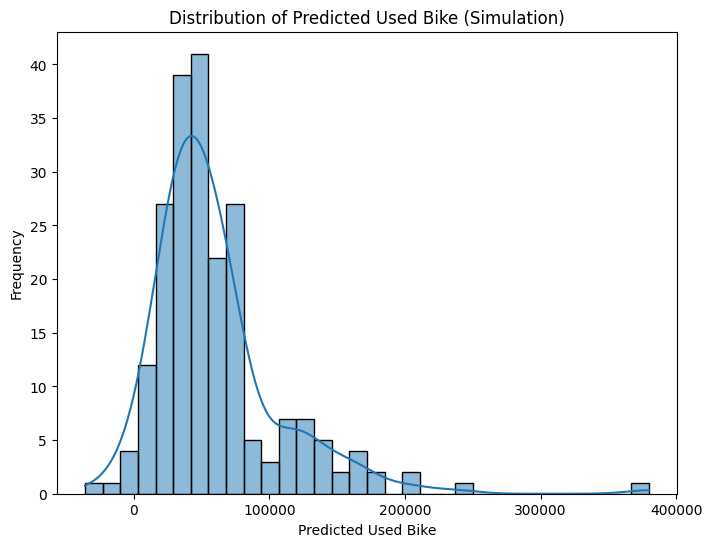

In [ ]:
# prompt: buatkan model simulation

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Import seaborn for histplot

# Assuming 'lr' is your trained LinearRegression model
# and 'X_test' contains the features of your test data.

# Generate simulated data similar to your X_test
# Use the size of X_test as the sample size, or a smaller number if desired
simulated_data = X_test.sample(n=len(X_test), random_state=42)  # Use len(X_test) for sample size

# Predict salary for the simulated data
# Changed 'model' to 'lr' and 'simulated_df' to 'simulated_data'
simulated_used_bike = lr.predict(simulated_data)

# Create a DataFrame to store the simulated data and predicted salaries
# Changed 'simulated_df' to 'simulated_data' and 'simulated_salary' to 'simulated_used_bike'
simulation_results = pd.DataFrame(simulated_data)
simulation_results['Predicted_Used_bike'] = simulated_used_bike

# Display the first few rows of the simulation results
print(simulation_results.head())


# You can further analyze the simulation results, for example:
# Calculate statistics of the predicted salaries:
print("\nSummary statistics of predicted Used Bike:")
print(simulation_results['Predicted_Used_bike'].describe())

# Visualize the distribution of predicted salaries:
plt.figure(figsize=(8, 6))
sns.histplot(simulation_results['Predicted_Used_bike'], kde=True) # Corrected to sns.histplot
plt.title('Distribution of Predicted Used Bike (Simulation)')
plt.xlabel('Predicted Used Bike')
plt.ylabel('Frequency')
plt.show()

# Analyze the impact of individual features on predicted salary (optional)
# ...  (add code to analyze the relationship between features and predicted_salary)

## Save Model

In [ ]:
# prompt: buatkan save model

import pickle
filename = 'finalized_model.sav'
pickle.dump(lr, open(filename, 'wb'))
# some time later...

# load the model from disk
loaded_model = pickle.load(open(filename, 'rb'))
result = loaded_model.score(X_test, y_test)
result


0.8061014923145154

In [ ]:
# prompt: buatkan streamlit dari code diatas

import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Load the trained model
filename = 'finalized_model.sav'
loaded_model = pickle.load(open(filename, 'rb'))

# Create Streamlit app
st.title("Used Motorcycle Price Prediction")

# Input features
st.sidebar.header("Input Features")
year = st.sidebar.slider("Year", 2001, 2021, 2018)
km_driven = st.sidebar.slider("Kilometers Driven", 0, 100000, 25000)
owner_second = st.sidebar.selectbox("Second Owner", [0, 1])
owner_third = st.sidebar.selectbox("Third Owner", [0, 1])
owner_fourth_above = st.sidebar.selectbox("Fourth Owner or Above", [0, 1])
seller_type_individual = st.sidebar.selectbox("Individual Seller", [0, 1])
brand_Bajaj = st.sidebar.selectbox("Bajaj Brand", [0, 1])
brand_Hero = st.sidebar.selectbox("Hero Brand", [0, 1])
brand_Honda = st.sidebar.selectbox("Honda Brand", [0, 1])
brand_KTM = st.sidebar.selectbox("KTM Brand", [0, 1])
brand_Royal_Enfield = st.sidebar.selectbox("Royal Enfield Brand", [0,1])
brand_Suzuki = st.sidebar.selectbox("Suzuki Brand", [0, 1])
brand_TVS = st.sidebar.selectbox("TVS Brand", [0, 1])
brand_Yamaha = st.sidebar.selectbox("Yamaha Brand", [0, 1])
brand_Other = st.sidebar.selectbox("Other Brand", [0,1])


# Create input array
input_data = np.array([[year, km_driven, owner_second, owner_third, owner_fourth_above, seller_type_individual,
                       brand_Bajaj, brand_Hero, brand_Honda, brand_KTM, brand_Royal_Enfield,
                       brand_Suzuki, brand_TVS, brand_Yamaha, brand_Other]])


# Min-Max scaling (replace with your actual min and max values)
min_values = np.array([2001, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
max_values = np.array([2021, 100000, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

normalized_input_data = (input_data - min_values) / (max_values - min_values)

# Make prediction
prediction = loaded_model.predict(normalized_input_data)

# Display prediction
st.subheader("Prediction")
st.write(f"Predicted Used Bike Price: {prediction[0]}")

# Display simulation results (optional)
st.subheader("Simulation Results")
# You can add code to display a chart or table of simulation results here,
# based on the simulated_results dataframe from your original code.
# For example:
# st.write(simulation_results)  # Display simulation results dataframe


# Add other visualizations or information as needed


In [ ]:
# prompt: buatkan streamlit

import streamlit as st
import pandas as pd
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression

# Load the saved model
filename = 'finalized_model.sav'
loaded_model = pickle.load(open(filename, 'rb'))

# Streamlit app
st.title("Used Motorcycle Price Prediction")

# Input features
st.header("Enter Motorcycle Details:")
year = st.number_input("Year", min_value=2001, max_value=2021, value=2018)
km_driven = st.number_input("Kilometers Driven", min_value=0, max_value=100000, value=25000)

owner_options = ['First Owner', 'Second Owner', 'Third Owner', 'Fourth & Above Owner']
owner = st.selectbox("Owner", owner_options)
owner_mapping = {'First Owner': 0, 'Second Owner': 1, 'Third Owner': 2, 'Fourth & Above Owner':3}
owner_encoded = owner_mapping[owner]


seller_type_options = ['Individual', 'Dealer']
seller_type = st.selectbox("Seller Type", seller_type_options)
seller_type_mapping = {'Individual':0, 'Dealer': 1}
seller_type_encoded = seller_type_mapping[seller_type]


brands = ['Bajaj', 'Hero', 'Honda', 'KTM', 'Other', 'Royal Enfield', 'Suzuki', 'TVS', 'Yamaha']
brand = st.selectbox("Brand", brands)
brand_dummies = {brand: 1}
for b in brands:
  if b != brand:
      brand_dummies[b] = 0

# Create input array for prediction
input_data = np.array([[year, km_driven, owner_encoded, seller_type_encoded,
                       brand_dummies['Bajaj'], brand_dummies['Hero'], brand_dummies['Honda'],
                       brand_dummies['KTM'], brand_dummies['Other'], brand_dummies['Royal Enfield'],
                       brand_dummies['Suzuki'], brand_dummies['TVS'], brand_dummies['Yamaha']]])


# Min-Max Scaling (replace with your actual min and max values)
min_values = np.array([2001, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])  # Example min values
max_values = np.array([2021, 100000, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])  # Example max values
normalized_input = (input_data - min_values) / (max_values - min_values)


# Make prediction
prediction = loaded_model.predict(normalized_input)

# Display prediction
st.header("Predicted Selling Price:")
st.write(f"The predicted selling price of the motorcycle is: {prediction[0]}")
